# Tricomi Kernel: Exact vs RFF Approximation

This notebook demonstrates the Random Fourier Feature (RFF) approximation for the Tricomi kernel.

## Kernel Definition

The Tricomi kernel is defined using Tricomi's confluent hypergeometric function U:
$$k(x, x') = \frac{\Gamma(\beta + \gamma)}{\Gamma(\gamma)} \cdot U\left(\beta, 1 - \gamma, \frac{\gamma}{\beta}\|x - x'\|^\alpha\right)$$

where:
- $\alpha \in (0, 2]$ controls the exponent
- $\beta > 0$ is the first parameter
- $\gamma > 0$ is the second parameter

### Spectral Mixing Distribution
The mixing distribution R follows an F-distribution:
$$R \sim F(2\beta, 2\gamma)$$

In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/GeneralizedRFF.jl`


In [2]:
using GeneralizedRandomFourierFeatures
using KernelFunctions
using KernelFunctions: ColVecs
using AbstractGPs
using Random
using LinearAlgebra
using Plots
gr()

Random.seed!(42)

TaskLocalRNG()

## 1. Kernel Profile Comparison

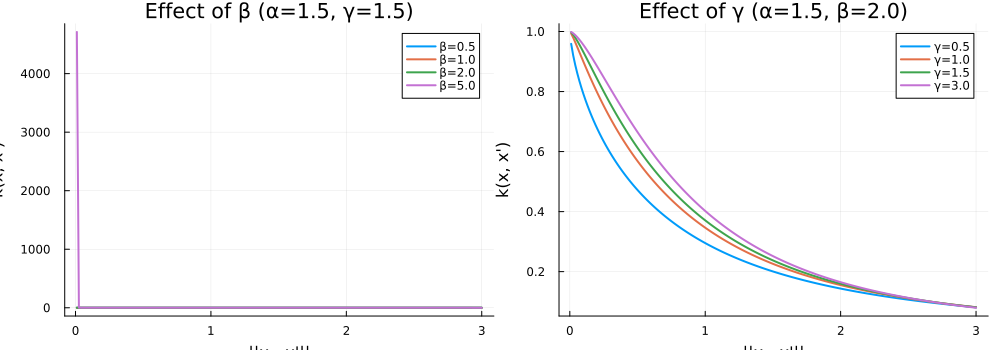

In [3]:
# Compare different parameter combinations
x_range = range(0.01, 3, length=200)  # Start from 0.01 to avoid potential numerical issues

# Vary beta with fixed alpha, gamma
p_beta = plot(title="Effect of β (α=1.5, γ=1.5)", xlabel="||x - x'||", ylabel="k(x, x')")
for β in [0.5, 1.0, 2.0, 5.0]
    k = TricomiKernel(α=1.5, β=β, γ=1.5)
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_beta, x_range, y_k, label="β=$β", linewidth=2)
end

# Vary gamma with fixed alpha, beta
p_gamma = plot(title="Effect of γ (α=1.5, β=2.0)", xlabel="||x - x'||", ylabel="k(x, x')")
for γ in [0.5, 1.0, 1.5, 3.0]
    k = TricomiKernel(α=1.5, β=2.0, γ=γ)
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_gamma, x_range, y_k, label="γ=$γ", linewidth=2)
end

plot(p_beta, p_gamma, layout=(1, 2), size=(1000, 350))

## 2. Kernel Matrix Comparison (Heatmap)

In [4]:
# Define kernel
k = TricomiKernel(α=1.5, β=2.0, γ=1.5)
println("Kernel: ", k)

Kernel: Tricomi Kernel (α = 1.5, β = 2.0, γ = 1.5, metric = Distances.Euclidean(0.0))


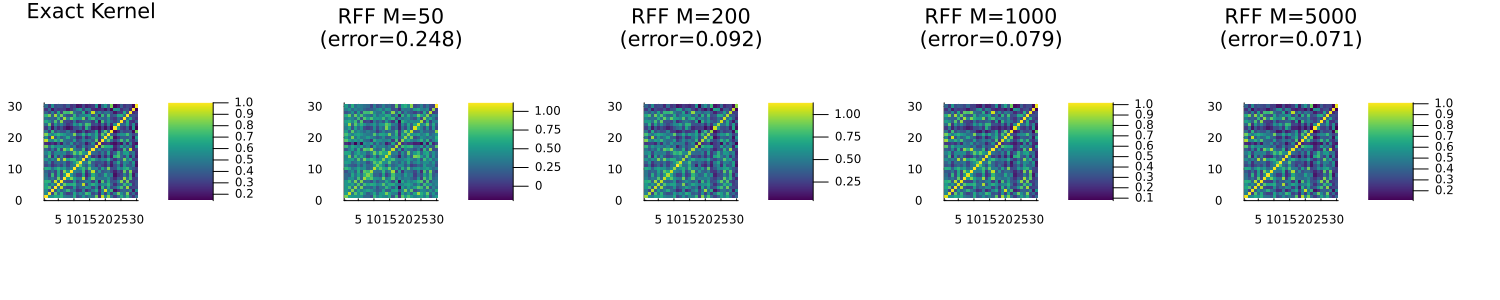

In [5]:
# Generate test data
n = 30
X = [rand(2) * 2 for _ in 1:n]

# Exact kernel matrix
K_exact = kernelmatrix(k, X)

# RFF approximation with different M values
M_values = [50, 200, 1000, 5000]

plots = [heatmap(K_exact, title="Exact Kernel", c=:viridis, aspect_ratio=1)]

for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    rel_error = norm(K_exact - K_approx) / norm(K_exact)
    push!(plots, heatmap(K_approx, title="RFF M=$M\n(error=$(round(rel_error, digits=3)))", 
                         c=:viridis, aspect_ratio=1))
end

plot(plots..., layout=(1, 5), size=(1500, 300))

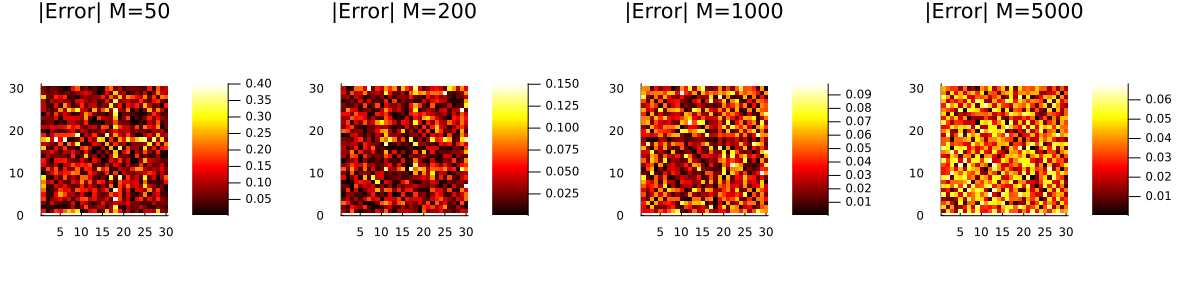

In [6]:
# Error difference heatmaps
error_plots = []
for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    K_diff = abs.(K_exact - K_approx)
    push!(error_plots, heatmap(K_diff, title="|Error| M=$M", c=:hot, aspect_ratio=1))
end

plot(error_plots..., layout=(1, 4), size=(1200, 300))

## 3. Convergence Analysis

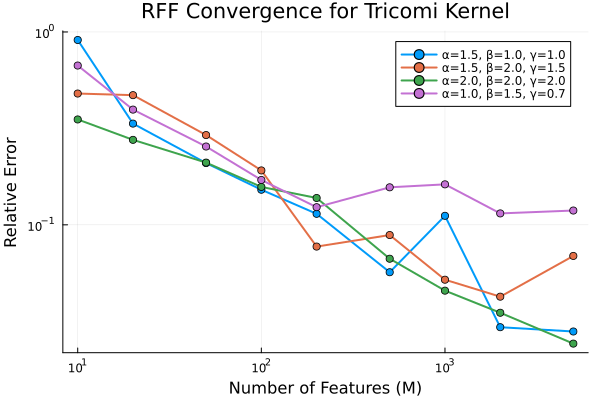

In [7]:
# Analyze convergence for different parameter combinations
M_range = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]

param_sets = [
    (1.5, 1.0, 1.0),
    (1.5, 2.0, 1.5),
    (2.0, 2.0, 2.0),
    (1.0, 1.5, 0.7)
]

p_conv = plot(title="RFF Convergence for Tricomi Kernel",
              xlabel="Number of Features (M)", ylabel="Relative Error",
              xscale=:log10, yscale=:log10, legend=:topright)

for (α, β, γ) in param_sets
    k_param = TricomiKernel(α=α, β=β, γ=γ)
    K_exact_param = kernelmatrix(k_param, X)
    
    errors = Float64[]
    for M in M_range
        K_approx = rff_kernelmatrix(MersenneTwister(42), k_param, X, M)
        rel_error = norm(K_exact_param - K_approx) / norm(K_exact_param)
        push!(errors, rel_error)
    end
    
    plot!(p_conv, M_range, errors, marker=:circle, label="α=$α, β=$β, γ=$γ", linewidth=2)
end

p_conv

## 4. 1D Gaussian Process Comparison

In [8]:
# RFF approximation for GP
function rff_gp_predict(k, X_train, y_train, X_test, M; noise=0.1)
    rng = MersenneTwister(42)
    d = length(first(X_train))
    basis = sample_generalized_rff_basis(rng, k, d, M)
    
    Phi_train_mat = hcat(X_train...)
    Phi_test_mat = hcat(X_test...)
    
    features_train = basis(ColVecs(Phi_train_mat))
    features_test = basis(ColVecs(Phi_test_mat))
    
    Phi_train = hcat([features_train[i] for i in 1:length(X_train)]...)'
    Phi_test = hcat([features_test[i] for i in 1:length(X_test)]...)'
    
    n, m = size(Phi_train)
    A = Phi_train' * Phi_train + noise^2 * I(m)
    w_mean = A \ (Phi_train' * y_train)
    
    m_pred = Phi_test * w_mean
    Sigma_w = noise^2 * inv(A)
    v_pred = [Phi_test[i, :]' * Sigma_w * Phi_test[i, :] + noise^2 for i in 1:size(Phi_test, 1)]
    
    return m_pred, sqrt.(v_pred)
end

rff_gp_predict (generic function with 1 method)

In [9]:
# Generate 1D data
n_train = 10
x_train = sort(rand(n_train) * 4 .- 2)
y_train = sin.(2 * x_train) .+ 0.2 * randn(n_train)

x_test = range(-2.5, 2.5, length=200)

X_train = [[x] for x in x_train]
X_test = [[x] for x in x_test]

# Exact GP
k_1d = TricomiKernel(α=1.5, β=2.0, γ=1.5)
f_exact = GP(k_1d)
fx_exact = f_exact(X_train, 0.1)
p_exact = posterior(fx_exact, y_train)

m_exact = mean(p_exact(X_test))
s_exact = sqrt.(var(p_exact(X_test)))

200-element Vector{Float64}:
 0.9822432156442726
 0.9815332322866698
 0.9807900894170606
 0.9800120089401145
 0.9791971045166545
 0.9783433741333377
 0.9774486920991522
 0.9765108004190842
 0.9755272994904892
 0.9744956380623424
 0.9734131023915933
 0.9722768045242409
 0.9710836696213782
 ⋮
 0.7222801927463357
 0.7393823504511724
 0.755209708350896
 0.7698776461750378
 0.7834888673322871
 0.7961350631601174
 0.8078983260619013
 0.8188523521084293
 0.8290634676413757
 0.8385915087304675
 0.8474905773740964
 0.8558096941550745

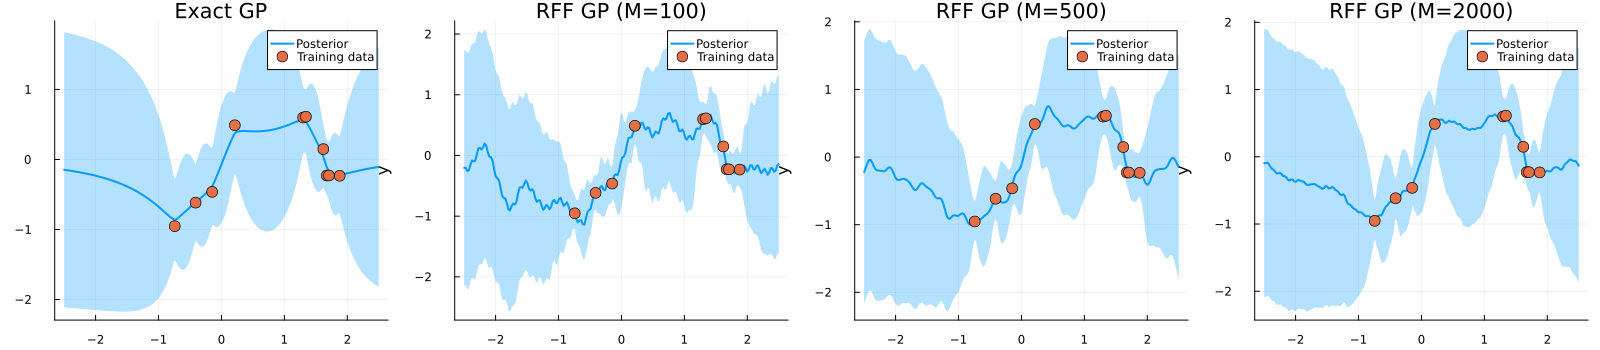

In [10]:
# Compare GP predictions
p1 = plot(title="Exact GP", xlabel="x", ylabel="y", legend=:topright)
plot!(p1, x_test, m_exact, ribbon=2*s_exact, fillalpha=0.3, label="Posterior", linewidth=2)
scatter!(p1, x_train, y_train, label="Training data", markersize=6)

M_vals = [100, 500, 2000]
rff_plots = []
for M in M_vals
    m_rff, s_rff = rff_gp_predict(k_1d, X_train, y_train, X_test, M)
    p = plot(title="RFF GP (M=$M)", xlabel="x", ylabel="y", legend=:topright)
    plot!(p, x_test, m_rff, ribbon=2*s_rff, fillalpha=0.3, label="Posterior", linewidth=2)
    scatter!(p, x_train, y_train, label="Training data", markersize=6)
    push!(rff_plots, p)
end

plot(p1, rff_plots..., layout=(1, 4), size=(1600, 350))

## 5. 2D Gaussian Process Comparison

In [11]:
# Generate 2D data
n_train_2d = 30
X_train_2d = [rand(2) * 4 .- 2 for _ in 1:n_train_2d]
y_train_2d = [sin(x[1]) * cos(x[2]) + 0.1 * randn() for x in X_train_2d]

# Test grid
x1_range = range(-2.5, 2.5, length=40)
x2_range = range(-2.5, 2.5, length=40)
X_test_2d = [[x1, x2] for x1 in x1_range for x2 in x2_range]

1600-element Vector{Vector{Float64}}:
 [-2.5, -2.5]
 [-2.5, -2.371794871794872]
 [-2.5, -2.2435897435897436]
 [-2.5, -2.1153846153846154]
 [-2.5, -1.9871794871794872]
 [-2.5, -1.858974358974359]
 [-2.5, -1.7307692307692308]
 [-2.5, -1.6025641025641026]
 [-2.5, -1.4743589743589745]
 [-2.5, -1.3461538461538463]
 [-2.5, -1.2179487179487178]
 [-2.5, -1.0897435897435896]
 [-2.5, -0.9615384615384616]
 ⋮
 [2.5, 1.0897435897435896]
 [2.5, 1.2179487179487178]
 [2.5, 1.3461538461538463]
 [2.5, 1.4743589743589745]
 [2.5, 1.6025641025641026]
 [2.5, 1.7307692307692308]
 [2.5, 1.858974358974359]
 [2.5, 1.9871794871794872]
 [2.5, 2.1153846153846154]
 [2.5, 2.2435897435897436]
 [2.5, 2.371794871794872]
 [2.5, 2.5]

In [12]:
# Exact GP for 2D
k_2d = TricomiKernel(α=1.5, β=2.0, γ=1.5)
f_exact_2d = GP(k_2d)
fx_exact_2d = f_exact_2d(X_train_2d, 0.1)
p_exact_2d = posterior(fx_exact_2d, y_train_2d)

m_exact_2d = mean(p_exact_2d(X_test_2d))
m_exact_grid = reshape(m_exact_2d, length(x1_range), length(x2_range))

40×40 Matrix{Float64}:
 -0.0862172  -0.085912   -0.0849394  -0.083294   …  -0.0356555   -0.0208157
 -0.0957858  -0.0956468  -0.0947155  -0.0929908     -0.0342609   -0.016521
 -0.106725   -0.10683    -0.105978   -0.104167      -0.0283285   -0.00797977
 -0.119283   -0.119752   -0.119048   -0.117146      -0.0153224    0.00647073
 -0.133756   -0.134783   -0.134359   -0.132397       0.00745087   0.0283664
 -0.150483   -0.152374   -0.152487   -0.150604   …   0.0418107    0.0585531
 -0.169819   -0.17304    -0.174153   -0.172733       0.0876374    0.0966592
 -0.192091   -0.197299   -0.200152   -0.199994       0.1426       0.140885
 -0.217528   -0.225562   -0.23118    -0.233553       0.202553     0.188114
 -0.24619    -0.258023   -0.267613   -0.274055       0.2617       0.234192
 -0.277917   -0.29458    -0.309394   -0.321385   …   0.31278      0.274589
 -0.312295   -0.334833   -0.3561     -0.374939       0.349492     0.305858
 -0.348629   -0.378082   -0.407058   -0.434042       0.370979     0.3

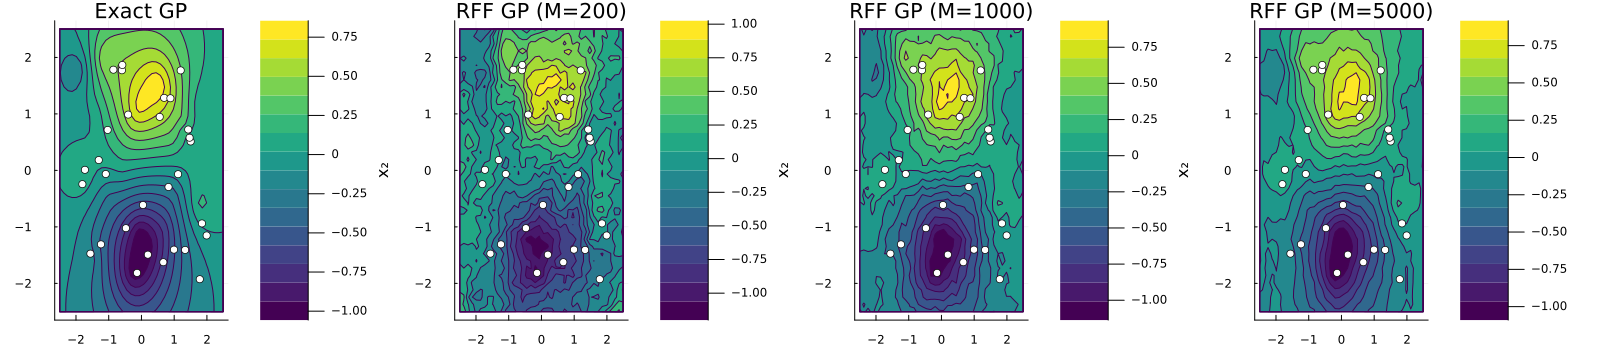

In [13]:
# Plot 2D comparison
p_exact_plot = contourf(x1_range, x2_range, m_exact_grid', 
                        title="Exact GP", xlabel="x₁", ylabel="x₂", c=:viridis)
scatter!(p_exact_plot, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
         c=:white, markersize=4, label="")

rff_2d_plots = [p_exact_plot]
for M in [200, 1000, 5000]
    m_rff_2d, _ = rff_gp_predict(k_2d, X_train_2d, y_train_2d, X_test_2d, M)
    m_rff_grid = reshape(m_rff_2d, length(x1_range), length(x2_range))
    
    p_rff = contourf(x1_range, x2_range, m_rff_grid', 
                     title="RFF GP (M=$M)", xlabel="x₁", ylabel="x₂", c=:viridis)
    scatter!(p_rff, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
             c=:white, markersize=4, label="")
    push!(rff_2d_plots, p_rff)
end

plot(rff_2d_plots..., layout=(1, 4), size=(1600, 350))

## 6. Comparison of All Kernels

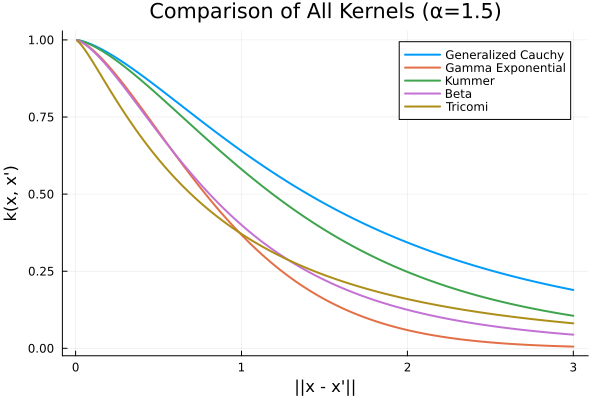

In [14]:
# Compare all kernel types from GeneralizedRandomFourierFeatures
x_range = range(0.01, 3, length=200)

kernels = [
    (GeneralizedCauchyKernel(1.5, 2.0), "Generalized Cauchy"),
    (GeneralizedRandomFourierFeatures.GammaExponentialKernel(γ=1.5), "Gamma Exponential"),
    (KummerKernel(α=1.5, β=2.0, γ=1.5), "Kummer"),
    (BetaKernel(α=1.5, β=2.0, γ=3.0), "Beta"),
    (TricomiKernel(α=1.5, β=2.0, γ=1.5), "Tricomi")
]

p_all = plot(title="Comparison of All Kernels (α=1.5)", 
             xlabel="||x - x'||", ylabel="k(x, x')", legend=:topright)

for (k, name) in kernels
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_all, x_range, y_k, label=name, linewidth=2)
end

p_all

## Summary

The Tricomi kernel RFF approximation:
- Uses F-distribution F(2β, 2γ) as the spectral mixing distribution
- The Tricomi U function gives unique kernel characteristics
- RFF approximation converges well with increasing M
- The kernel is well-suited for GP regression tasks

### Relationship to Other Kernels
- All kernels in this package use the spectral mixture representation from Langrené et al. (2024)
- Different mixing distributions (Gamma, Beta, F-distribution) lead to different kernel families
- The Tricomi kernel is particularly flexible due to its three parameters